# CSCI 6032: Homework 2

## Working Safely with Agents, Git, Docker, and Skills

This homework is about **using AI agents effectively and safely**. It is not about how a language model works internally. You will install GitHub Copilot CLI, give an agent a bounded workspace, use Git checkpoints before delegating changes, construct a reproducible Linux development container, run an agent inside that container, and create a reusable skill that helps submit the completed homework.

The notebook is the spine of your submission. Treat it as a laboratory notebook: record what you tried, what happened, false starts, corrections, and what you learned. The code, tests, `Dockerfile`, agent instructions, and skill must remain as ordinary files in the repository.

**Due: Thursday, September 17, 2026, 11:00 PM.**

## Learning objectives

After completing this homework, you should be able to:

1. Install, authenticate, and run a command-line coding agent.
2. Explain the difference between instructions, permissions, and an operating-system sandbox.
3. Restrict an agent to a designated project directory.
4. Use Git commits as recovery checkpoints before and after agent work.
5. Inspect and test an agent's changes rather than accepting them blindly.
6. Build and run a small Linux development environment with Docker.
7. Bind-mount a host repository into a container without exposing unrelated host files.
8. Run GitHub Copilot CLI inside the container and verify that changes persist on the host.
9. Package a repeated workflow as an agent skill.
10. Use browser automation with explicit human approval at an irreversible step.

## Grading and use of AI

You may use AI in any way you find useful on this homework. You remain responsible for every command you approve, every file you submit, and every claim in this notebook.

This homework is graded primarily on **completeness; reproducible evidence; and thoughtful reflection**. A failed attempt can be valuable evidence when you explain the failure and how you diagnosed it.

Never present an agent's statement as verification. Verification means that you inspected the relevant state yourself—for example, with `git status`, `git diff`, a test command, a file listing, or a Blackboard confirmation page.

## Safety rules

These rules apply throughout the assignment.

- Never place passwords, API keys, access tokens, private keys, authentication cookies, browser profiles, or Blackboard credentials in the repository, notebook, prompts, Dockerfile, image, skill, or screenshots.
- Redact usernames, email addresses, tokens, device codes, and other private information from captured output.
- Launch the host agent from the homework repository—not from your home directory or a broad parent directory.
- Read each requested command before approving it. Deny a command you do not understand and ask the agent to explain.
- Do not use destructive Git commands, rewrite history, or force-push.
- Do not mount your home directory, `.ssh`, or Docker socket into the container.
- Authenticate interactively. Do not put credentials in the Dockerfile or bake them into an image layer.  You can login using the browser and then let copilot drive from there when you want to automate the web.
- You must personally authenticate to Blackboard.

If you accidentally expose a credential, revoke it. Removing it in a later commit does not remove it from Git history.  You can rewrite git history, but it must be done explicitly.

## What you will submit

You will create a GitHub repository named:

```text
csci6032-hw2-<your-github-username>
```

Clearly anyone can look at this repository.  That is fine.

The repository will contain this completed notebook and the supporting artifacts. At the end, your submission skill will prepare a compressed archive from a clean, committed revision and use your authenticated browser session to help submit:

1. `CSCI6032_hw2.ipynb`
2. `csci6032-hw2-<your-github-username>.tar.gz`
3. The URL of the public GitHub repository.

Do not include the repository's `.git` directory in the archive. The public GitHub repository preserves the Git history.

If publishing your repository would expose information that should not be public, contact the instructor before publishing it.

## Part 0. Access and preparation (5 points)

Use your own GitHub account. If you do not already have Copilot access, request the GitHub Education student benefit immediately. Approval can take time. GitHub Copilot CLI is available with current Copilot plans; consult the instructor if account approval becomes a blocker.

Related links:

- [GitHub Education](https://github.com/education)
- [Install GitHub Copilot CLI](https://docs.github.com/en/copilot/how-tos/copilot-cli/set-up-copilot-cli/install-copilot-cli)
- [Authenticate GitHub Copilot CLI](https://docs.github.com/en/copilot/how-tos/copilot-cli/set-up-copilot-cli/authenticate-copilot-cli)

Record:

- your host operating system and version;
- the date you requested or confirmed Copilot access;
- whether access is active;
- any setup obstacle and how you addressed it.

Do not include personal documents or screenshots from the student-verification process.

### Part 0 laboratory record

**Host operating system and version:**

**Answer**

WRITE HERE

I am using my Macbook Pro, so MacOS Tahoe 26.5.2


**Copilot access status and date:**

**Answer**

It denied me after my first application to join Github Education, but the second time it accepted me (both on 9/11). As of now, it says I will be able to use the benefits in 72 hours.

**Setup notes, including any false starts:**

**Answer**

WRITE HERE
copilot download went smoothly, and my education subscription worked so yay! I can't log in yet (9/13), so I will have to wait until tomorrow to attempt the login again. It is letting me login now (9/14) but I am unable to do anything yet. It keeps immediately closing out after I run copilot login.

## Part 1. Install and run GitHub Copilot CLI on the host (10 points)

Install the current stable GitHub Copilot CLI using one of the methods in the official documentation. Record the method and version; do not assume that commands copied from an old tutorial remain current.

After installation:

1. Run `copilot version`.
2. Run `copilot login` or start `copilot` and use `/login`.
3. Complete the interactive browser or device-code flow yourself.
4. Start an interactive session and enter this prompt:

```text
Reply with exactly: Hello, CSCI 6032.
```

5. Exit the agent cleanly.

This is the agent equivalent of a Hello World exercise. It verifies access before the assignment introduces files, tools, and permissions.

### Part 1 laboratory record

Record the installation method, the redacted output of `copilot version`, and the Hello World response. Do not paste authentication codes, tokens, or account details.

**Answer**

WRITE HERE

Download went smoothly, but logging in was a bit of a struggle.
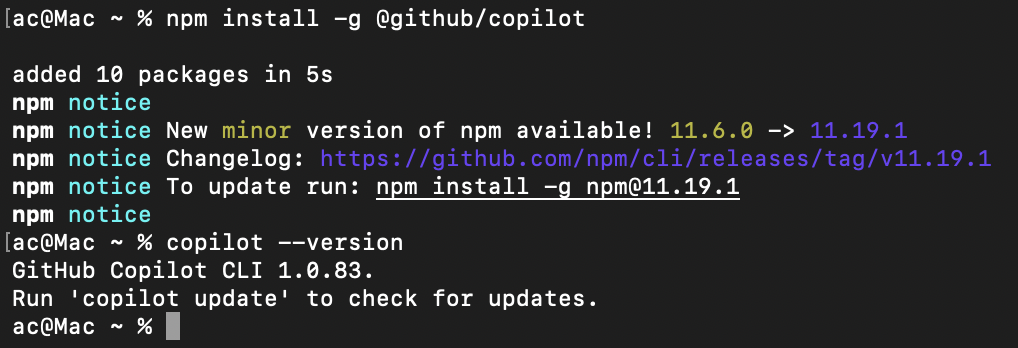

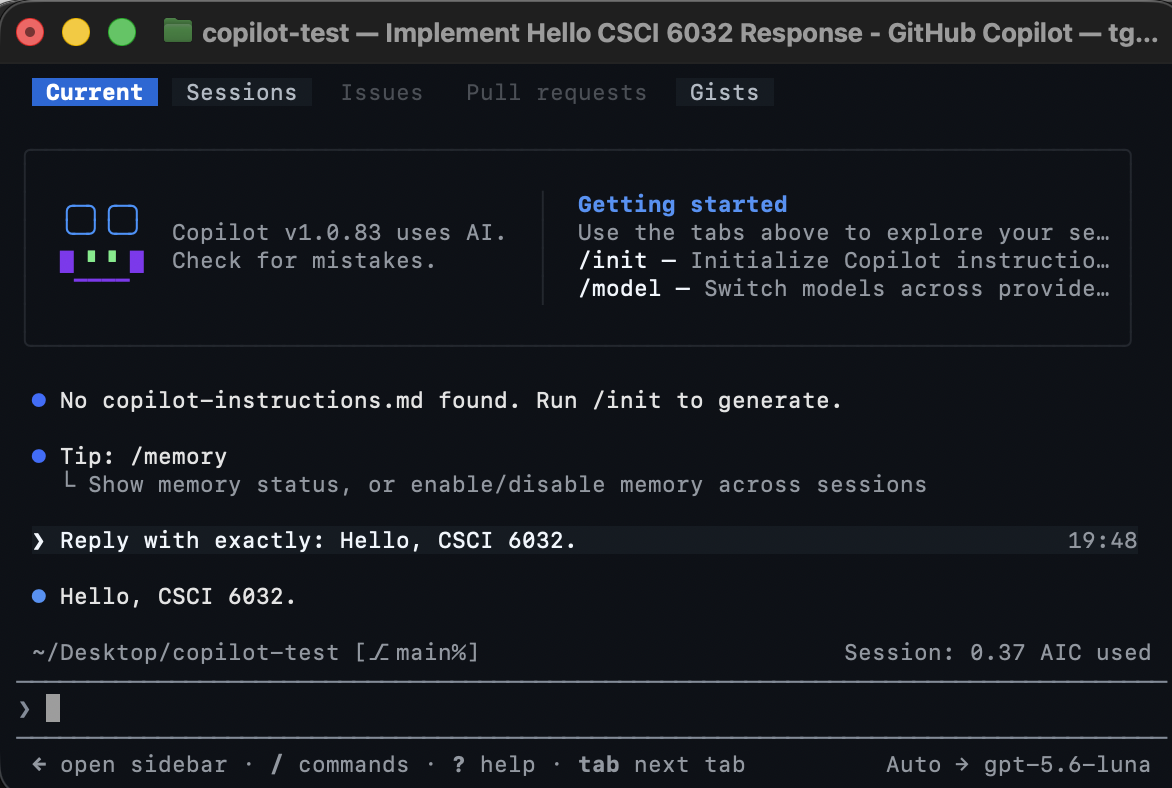

What, if anything, did the model need permission to do for the Hello World prompt? Why?

**Answer**

WRITE HERE
I am confused
It asked to access my entire home directory, so I decided to make a folder called "copilot-test" to run the hello world prompt. So I guess all it really needed was a directory to run in.

## Part 2. Create the repository and its first checkpoint (10 points)

On GitHub, create the public repository named `csci6032-hw2-<your-github-username>`, initialize it with a `README.md`, and clone it onto your host computer.

Copy this notebook into the repository root as `CSCI6032_hw2.ipynb`. Add a small UTF-8 text file named `sample.txt` containing at least five lines of text that you wrote yourself. Update `README.md` with the course, homework title, repository URL, your host operating system, and a short description.

Before invoking an agent on the repository, inspect the state:

```bash
git remote -v
git status
git diff
```

Commit and push these initial files. Use this commit message:

```text
checkpoint: repository before agent changes
```

Create and switch to a branch named `agent-work` before continuing. Confirm that the working tree is clean.

### Part 2 laboratory record

Paste a concise, redacted record showing:

- the repository URL;
- the initial checkpoint commit identifier;
- the current branch;
- a clean `git status` after the checkpoint.

**Answer**

WRITE HERE


1.https://github.com/aclee5-ai/csci6032-hw2-aclee5-ai

2. 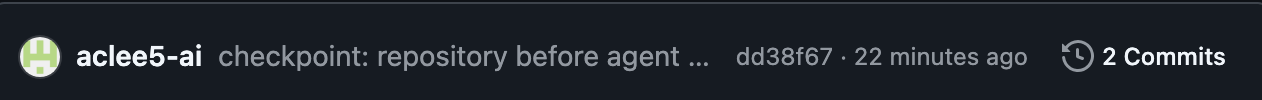

3. Currently in the agent-work branch

4.ac@Mac csci6032-hw2-aclee5-ai % git status
On branch agent-work
nothing to commit, working tree clean

Why is a commit more useful than merely copying a few files before an agent works?

**Answer**

WRITE HERE

I don't know for sure but it makes more sense to me to commit all of your changes before an agent works because you never know what it will need access to, and it seems better to be working with the most current version.

## Part 3. Constrain the host agent (10 points)

Create `AGENTS.md` at the root of the repository. You may ask an agent to draft it, but you must inspect and revise the result. It must instruct agents to:

1. Work only inside the current repository.
2. Never read, print, store, commit, or upload secrets, credentials, private keys, browser data, or configuration files that may contain them.
3. Explain an intended change before editing.
4. Ask before installing software, accessing a new network destination, deleting files, changing Git history, committing, or pushing.
5. Preserve uncommitted user work and avoid destructive Git commands and force-pushes.
6. Check `git status` before editing and stop if unrelated changes are present.
7. Make small, reviewable changes.
8. Show `git diff` after editing and run the smallest relevant test.
9. Explain errors rather than silently ignoring them.
10. Never claim success without checking the requested result.

Start Copilot CLI from the repository root. Enable local sandboxing when it is available, then inspect its actual state and policy with:

```text
/sandbox enable
/sandbox status
/sandbox policy
```

The current working directory should be writable; unrelated host locations should not be writable. Do not add broad path grants. If local sandboxing is unavailable on your platform or version, document that result and rely on the repository boundary, permission prompts, and the Docker phase that follows.

Commit `AGENTS.md` with the message `docs: add agent safety instructions` and push the branch.

### Part 3 laboratory record

Summarize the effective sandbox policy without exposing personal paths. State whether sandboxing was active and whether you changed any default permissions.

**Answer**

WRITE HERE

Using /sandbox enable, /sandbox status, and /sandbox policy gave me an error every time: unknown command: /sandbox.
Because of this I went into /help to see what prompts I could use to see what permissions copilot had. I ended up using /list-dirs to confirm it only had access to my repository, a temporary path, and the copilot plugins folder.



Explain why `AGENTS.md` is useful but is not, by itself, a security boundary.

**Answer**

WRITE HERE

I think it is helpful because it gives the agent a list of instructions to follow, but I don't think it is strong enough in its directions to be considered a security boundary. There is too much grey area with only 10 sentences of instructions to be confident in calling it a security boundary.

## Part 4. Generate and review code with the host agent (15 points)

Begin with a clean working tree on `agent-work`. Ask the host agent to complete this bounded task:

```text
Create a small Python command-line program in src/text_stats.py. It must read
one UTF-8 text file and print JSON containing the number of lines, words, and
characters. Add tests using Python's built-in unittest framework, document the
usage in README.md, and test the program with sample.txt. Do not add external
Python dependencies. Do not commit or push. Before editing, explain your plan;
after editing, show the diff and run the tests.
```

You may clarify the prompt or help the agent recover from errors. Do not ask it to work outside the repository.

When it finishes:

1. Run `git status` and `git diff` yourself.
2. Read every changed file.
3. Run the tests yourself.
4. Run the program on `sample.txt` and independently check at least one reported count.
5. Correct any problem, recording whether you or the agent made the correction.
6. Commit the reviewed result as `feat: add agent-generated text statistics tool`.
7. Push `agent-work`.

### Part 4 laboratory record

Record the exact prompt you used if it differs from the supplied prompt. Include selected agent output that shows planning, tool use, and verification; do not paste an enormous transcript.

**Answer**

WRITE HERE

I used the exact prompt provided. Below are a few outputs from the agent:

"I'll first check the repository status and existing project layout. Then I'll add the CLI, built-in unittest coverage, README usage, and sample.txt, show the resulting diff, and run the targeted tests plus the sample command."

"The implementation, tests, and README usage are now added. I'll inspect the exact diff, then run the built-in test suite and execute the CLI against sample.txt to confirm the documented behavior."

"Implemented the text statistics CLI without external dependencies.

• Added src/text_stats.py to read a UTF-8 file and print JSON counts for lines, words, and characters.
• Added tests/test_text_stats.py using built-in unittest.
• Documented usage in README.md.
• Tested with sample.txt, producing:
{"characters": 208, "lines": 5, "words": 43}

All 3 tests pass. Changes remain uncommitted and unpushed."

Record the test command and result, the independent check you performed, and the commit identifier.

**Answer**

WRITE HERE

python3 -m unittest discover -s tests
...
----------------------------------------------------------------------
Ran 3 tests in 0.046s

OK

For my independent check, I used the following commands: wc -l sample.txt
       5 sample.txt

wc -w sample.txt
      43 sample.txt
      
wc -w sample.txt
      43 sample.txt

The commit identifier is: 7e39a9d


What did you inspect before deciding that the change was safe to commit? Did the agent do anything unexpected?

**Answer**

WRITE HERE

I had no expectations going into this so there wasn't anything in particular that was unexpected. To be honest I did not really inspect anything other than running the tests above.

## Part 5. Install and verify Docker on the host (10 points)

Install Docker Desktop or Docker Engine using the current official instructions for your operating system:

- [Docker Desktop overview and platform installers](https://docs.docker.com/desktop/)
- [Docker Engine installation](https://docs.docker.com/engine/install/)

Start Docker and verify it from a host terminal:

```bash
docker version
docker run --rm hello-world
```

The first command should show both client and server information. The second should retrieve and run a small test image successfully.

If institutional or hardware restrictions prevent a normal installation, contact the instructor early rather than weakening the assignment's safety requirements.

### Part 5 laboratory record

Record the Docker product, installation method, version, and a concise excerpt showing that `hello-world` ran. Note any virtualization, WSL, permission, or architecture issue you encountered.

**Answer**

WRITE HERE

Installed Docker Desktop for mac from here: https://www.google.com/url?q=https%3A%2F%2Fdocs.docker.com%2Fdesktop%2F

The version is 4.91.0
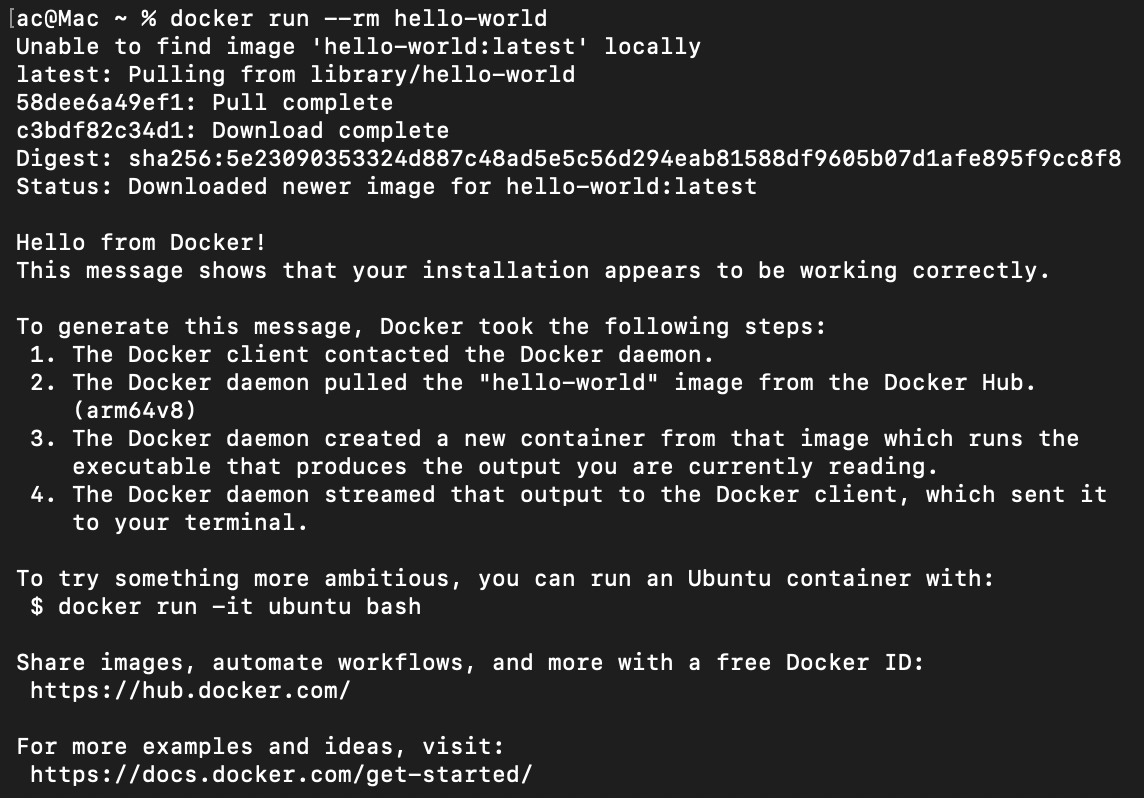

## Part 6. Create a minimal Linux agent development image (15 points)

Use an agent to help create a `Dockerfile`, but inspect and understand every instruction. The image must provide:

- a small, current Linux base suitable for Python development;
- Python 3.12 or later and `pip`;
- Git;
- GitHub CLI (`gh`);
- the current stable GitHub Copilot CLI;
- certificates and only the additional utilities needed for installation;
- a non-root development user;
- `/workspace` as the working directory.

The image must **not** contain your repository, tokens, credentials, browser profile, Docker socket, or a copy of a host credential directory. Do not use a floating prerelease of Copilot CLI. Prefer a reproducible version argument or record the resolved Copilot version.

Build the image with the tag:

```text
csci6032-hw2-agent
```

Start an interactive container with only the homework repository bind-mounted read/write at `/workspace`. Docker recommends the explicit `--mount` syntax. Have your agent adapt the following pattern to your shell and operating system:

```text
docker run --rm -it --mount type=bind,src=<ABSOLUTE-PATH-TO-REPOSITORY>,dst=/workspace csci6032-hw2-agent
```

Do not mount a broad parent directory. On native Linux, you may need to account for the host user's UID and GID so the non-root container user can write to the mounted repository; document any adjustment.

Inside the container, verify:

```bash
id
pwd
python --version
git --version
gh --version
copilot version
git status
```

Authenticate `gh` and Copilot interactively from inside the container using their browser/device flows. Do not paste a token into a Docker command, Dockerfile, notebook, or shell history. Demonstrate GitHub access with a read-only command such as `gh repo view`; redact account details in the notebook.

### Part 6 laboratory record

Paste your complete `Dockerfile` here as a fenced code block. Explain the purpose of each major layer and how the non-root user is created.



**Answer**

WRITE HERE

```
FROM python:3.12-slim-bookworm

ARG COPILOT_CLI_VERSION=1.0.85

ENV PYTHONDONTWRITEBYTECODE=1 \
    PYTHONUNBUFFERED=1

RUN set -eux; \
    apt-get update; \
    apt-get install --no-install-recommends -y \
        ca-certificates \
        curl \
        git \
        gnupg; \
    install -d -m 0755 /etc/apt/keyrings; \
    curl -fsSL https://cli.github.com/packages/githubcli-archive-keyring.gpg \
        -o /etc/apt/keyrings/githubcli-archive-keyring.gpg; \
    chmod go+r /etc/apt/keyrings/githubcli-archive-keyring.gpg; \
    printf '%s\n' \
        'deb [arch=amd64,arm64,armhf signed-by=/etc/apt/keyrings/githubcli-archive-keyring.gpg] https://cli.github.com/packages stable main' \
        > /etc/apt/sources.list.d/github-cli.list; \
    curl -fsSL https://deb.nodesource.com/gpgkey/nodesource-repo.gpg.key \
        | gpg --dearmor -o /etc/apt/keyrings/nodesource.gpg; \
    printf '%s\n' \
        'deb [signed-by=/etc/apt/keyrings/nodesource.gpg] https://deb.nodesource.com/node_22.x nodistro main' \
        > /etc/apt/sources.list.d/nodesource.list; \
    apt-get update; \
    apt-get install --no-install-recommends -y \
        gh \
        nodejs; \
    npm install --global "@github/copilot@${COPILOT_CLI_VERSION}"; \
    npm cache clean --force; \
    apt-get purge --auto-remove -y \
        gnupg; \
    rm -rf /var/lib/apt/lists/*

RUN useradd --create-home --shell /bin/bash dev \
    && mkdir --parents /workspace \
    && chown --recursive dev:dev /workspace

USER dev
WORKDIR /workspace

CMD ["/bin/bash"]
```

RUN useradd is how the non-root user is created as well as its own home directory and bash as its default shell. After that, workspace is created and the ownership is changed to the new user. The purpose of each major layer is as follows: layer 1: base image, which starts with a small, official image that already has python. Layer 2: build: this defines the variable for which copilot CLI to install. Layer 3: environment variables, which stops python from writing cache fyles and makes the output print immediately. Layer 4: the first run, which installs all of the base utilities needed. Layer 5: non-root user: creates linux user with its own home directory etc. Layer 6: user and workdir: sitches all commands to execute as the dev user and sets the default folder to workspace when you start the container.

Record the exact build and run commands with private path components replaced by a placeholder. Include concise, redacted verification output from inside the container.

**Answer**

WRITE HERE

The build command was: docker build -t csci6032-hw2-agent .
and the run command I had to change a few times to get it to put me in bash and not directly into python: docker run --rm -it --mount type=bind,src=/Users/ac/csci6032-hw2-aclee5-ai,dst=/workspace csci6032-hw2-agent

I also had some issues with logging into copilot inside of the workspace but solved it by storing my auth token and exporting it to the copilot login.

What host resources can the container modify through the bind mount? What important resources did you deliberately not mount?

**Answer**

WRITE HERE


The only host resources the container can modify through the bind mount is the homework folder I mounted in my run command. I didn't mount anything else because I didn't want it to have access to anything else in my home directory.

## Part 7. Run an agent inside the container (10 points)

Before the container agent edits anything, return to the host, inspect the repository, and commit the reviewed `Dockerfile` and current notebook with the message:

```text
checkpoint: add container before container agent changes
```

Confirm that the tree is clean. Start the container again with the repository mounted at `/workspace`, launch Copilot CLI from `/workspace`, confirm the sandbox and repository boundary, and give it this task:

```text
Extend src/text_stats.py with an optional --top N argument that reports the N
most frequent words, case-insensitively, with deterministic tie-breaking.
Update the unittest tests and README.md. Do not add external dependencies. Do
not commit or push. First inspect the existing project and explain your plan.
After editing, show the diff and run all tests.
```

After the agent finishes:

1. Exit the container.
2. Confirm on the host that the bind-mounted changes persisted.
3. Inspect the entire diff and run the tests on the host.
4. Try the new option with `sample.txt` and check the result.
5. Commit the reviewed change as `feat: add top-words option from container agent`.
6. Push the branch.

### Part 7 laboratory record

Provide selected evidence that Copilot ran inside the container, changed the bind-mounted repository, and ran tests. Include the checkpoint and post-agent commit identifiers.

**Answer**

WRITE HERE

Describe at least one difference between running the agent directly on the host and running it in the container. Which boundary protected the host, and which host files were intentionally exposed?

**Answer**

WRITE HERE

## Part 8. Add browser tools on the host (5 points)

Return to the **host** Copilot installation for this part. Do not attempt to share your Chrome profile with the development container.

GitHub Copilot CLI includes Playwright browser tools. To allow an agent to operate a tab in your existing authenticated Chrome session, install the instructor-approved [Playwright MCP Bridge extension](https://github.com/microsoft/playwright/tree/main/packages/extension) and configure a project-level Playwright MCP server in extension mode by following the current [Playwright MCP documentation](https://github.com/microsoft/playwright-mcp) and [GitHub Copilot MCP documentation](https://docs.github.com/en/copilot/how-tos/copilot-cli/customize-copilot/add-mcp-servers).

Important boundaries:

- Install only the extension linked by the instructor.
- Review the permissions Chrome requests.
- Connect only the Blackboard tab needed for this assignment.
- Keep the default connection approval; do not store an extension connection token in the repository.
- Project MCP configuration is executable configuration. Read it before trusting the folder.
- Test the browser connection with a read-only action, such as asking the agent to report the title of the selected tab.

Do not allow the agent to submit anything during this test.

### Part 8 laboratory record

Record the extension name and source, the location of the MCP configuration, and the result of the read-only browser test. Do not paste cookies, tokens, Blackboard contents, grades, or personal information.

**Answer**

WRITE HERE

What additional authority did connecting the browser give the agent?

**Answer**

WRITE HERE

## Part 9. Create a Blackboard submission skill (5 points)

Create a project skill at:

```text
.github/skills/blackboard-submission/SKILL.md
```

You may use Copilot to draft the skill. The `SKILL.md` file must have valid YAML frontmatter containing a lowercase hyphenated `name` and a precise `description`. Do not include `allowed-tools: "*"`, and do not preapprove shell or browser tools. The point is to preserve visible permission boundaries.

The skill must implement this workflow:

1. Confirm that it is operating in the expected homework repository.
2. Run a preflight that checks the current branch, `git status`, recent commits, expected remote URL, and required files.
3. Stop if the tree is not clean, required artifacts are absent, or unresolved secrets/private data are apparent.
4. Confirm that the reviewed branch has been pushed.
5. Prepare `csci6032-hw2-<your-github-username>.tar.gz` from the committed `HEAD` without including `.git`, credentials, caches, or unrelated files.
6. List the archive contents and show the exact notebook, archive, repository URL, and submission text it proposes to use.
7. Support a **dry run** that performs every possible check without opening Blackboard or submitting.
8. Ask before opening or controlling the Blackboard tab.
9. Require the student to authenticate personally; never request, read, store, type, or expose credentials.
10. Navigate only to this homework's submission page and stage the required files and repository URL.
11. Stop immediately before the final, irreversible submission action and show the student exactly what will be submitted.
12. Require explicit confirmation at that point. A prior general approval is not sufficient.
13. After confirmation, complete the submission, verify the confirmation page or receipt, and report the result.
14. Do not commit Blackboard screenshots, receipts, browser data, or personal information to the public repository.

Review the current [GitHub agent skills documentation](https://docs.github.com/en/copilot/how-tos/copilot-cli/customize-copilot/add-skills). Reload and inspect the skill with `/skills reload`, `/skills list`, and `/skills info blackboard-submission`.

Commit the skill and final notebook changes as:

```text
feat: add Blackboard submission skill
```

Push the branch. Then return to your repository's default branch, merge
`agent-work` **without squashing**, and push the default branch. Resolve and
review any conflict rather than asking Git to discard one side. Run the tests
again after the merge. The default branch, working tree, and remote must agree
before you create the submission archive.

### Part 9 laboratory record

Paste your complete `SKILL.md` here as a fenced code block.

**Answer**

WRITE HERE

Describe one material change you made after reviewing the agent's draft of the skill.

**Answer**

WRITE HERE

Why must the skill ask again immediately before the final submission action?

**Answer**

WRITE HERE

## Part 10. Dry-run and use the submission skill

Invoke `/blackboard-submission` in dry-run mode first. Resolve every reported problem. Inspect the archive contents yourself, confirm the repository is public and up to date, and confirm that no secret or private information is included.

Then invoke the skill for the real submission. Personally authenticate to Blackboard. Let the skill prepare the submission, inspect the staged files and text, and provide explicit confirmation only when they are correct. Verify the resulting Blackboard confirmation.

Do not modify the committed notebook afterward merely to record that submission succeeded; doing so would make the submitted archive differ from the repository checkpoint. Instead, enter this short statement in Blackboard alongside the repository URL:

```text
I used my blackboard-submission skill, reviewed the staged artifacts, explicitly
approved the final submission action, and verified Blackboard's confirmation.
```

If the automation cannot safely complete the final click, perform that click yourself, verify the result, and explain the limitation in the Blackboard comment. Safe human completion is preferable to bypassing a security boundary.

## Required Git history and repository contents

Your public repository must show, at minimum, these ordered checkpoints:

1. `checkpoint: repository before agent changes`
2. `docs: add agent safety instructions`
3. `feat: add agent-generated text statistics tool`
4. `checkpoint: add container before container agent changes`
5. `feat: add top-words option from container agent`
6. `feat: add Blackboard submission skill`

Equivalent additional commits are welcome. Do not squash these checkpoints.

Required contents:

```text
CSCI6032_hw2.ipynb
README.md
AGENTS.md
sample.txt
Dockerfile
src/
  text_stats.py
tests/
  test_text_stats.py
.github/
  skills/
    blackboard-submission/
      SKILL.md
```

Your project-level MCP configuration may be committed only if it contains no secret, personal path, browser data, or extension token. Otherwise, document its structure in the notebook and exclude it from the repository.

## Final reflection (5 points)

Answer each question in a short paragraph.

1. Where did Git provide protection, and where did it not?
2. How did the host sandbox and Docker container differ as boundaries?
3. Which agent output required the most human judgment?
4. What did the agent do that saved you time?
5. What would you change before allowing an agent to work on a valuable research repository?

**Answer**

WRITE HERE


## Grading summary

| Component | Points |
|---|---:|
| Access and preparation | 5 |
| Host Copilot installation and Hello World | 10 |
| Repository and initial checkpoint | 10 |
| Agent instructions and host boundary | 10 |
| Host-agent code generation and review | 15 |
| Docker installation | 10 |
| Linux agent development image | 15 |
| Agent work inside the container | 10 |
| Browser tools | 5 |
| Submission skill | 5 |
| Final reflection | 5 |
| **Total** | **100** |

The real Blackboard submission is required for the homework to be received. If browser automation fails after a documented good-faith attempt, submit manually and document the limitation in the Blackboard comment.

## Documentation references

These links were checked when the assignment was prepared. Tools change quickly; use the current official page when its interface differs from this notebook.

- [Installing GitHub Copilot CLI](https://docs.github.com/en/copilot/how-tos/copilot-cli/set-up-copilot-cli/install-copilot-cli)
- [Authenticating GitHub Copilot CLI](https://docs.github.com/en/copilot/how-tos/copilot-cli/set-up-copilot-cli/authenticate-copilot-cli)
- [Using local sandboxing](https://docs.github.com/en/copilot/how-tos/cloud-and-local-sandboxes/using-local-sandboxing)
- [Allowing and denying Copilot CLI tools](https://docs.github.com/en/copilot/how-tos/copilot-cli/use-copilot-cli/allowing-tools)
- [Adding agent skills](https://docs.github.com/en/copilot/how-tos/copilot-cli/customize-copilot/add-skills)
- [Adding MCP servers](https://docs.github.com/en/copilot/how-tos/copilot-cli/customize-copilot/add-mcp-servers)
- [Docker Desktop](https://docs.docker.com/desktop/)
- [Docker Engine installation](https://docs.docker.com/engine/install/)
- [Docker bind mounts](https://docs.docker.com/engine/storage/bind-mounts/)
- [Playwright MCP](https://github.com/microsoft/playwright-mcp)
- [Playwright MCP Bridge extension](https://github.com/microsoft/playwright/tree/main/packages/extension)